In [1]:
# Uncomment the below line if using Kaggle P100
#!pip install --force-reinstall torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu126

In [2]:
import os
import math
import random
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, classification_report,
    roc_curve, average_precision_score, precision_score, recall_score, f1_score
)

from tqdm.auto import tqdm

In [3]:
# Config - Paths
DATA_DIR  = Path("/user/HS401/ep01372/Documents/AML_Project/inputs/melanoma-dataset-512/siim_isic_512")
CSV_PATH  = DATA_DIR / "train_resized_512.csv"
TEST_CSV_PATH = DATA_DIR / "test_resized_512.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

IMAGE_DIR = DATA_DIR / "train"
TEST_IMAGE_DIR = DATA_DIR / "test"

# === EXPERIMENT NAME ===
EXPERIMENT_NAME = "b7_512_hybrid16_residualGated_meta_frozenCNNv2"
OUTPUT_DIR = Path("/vol/research/ep01372") / f"outputs_{EXPERIMENT_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:

# Config - Hyperparameters (all original b7 values preserved)
SEED = 42
VALID_FRACTION = 0.10

USE_DATAPARALLEL = False

MODEL_NAME = "tf_efficientnet_b7_ns"
IMAGE_SIZE = 512
DROPOUT = 0.30
META_HIDDEN = 128


NUM_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 3
BATCH_SIZE = 4

# Optimizer hyperparameters
CNN_LR = 1e-5
META_LR = 1e-4
HEAD_LR = 1e-4

TRANSFORMER_LR = 5e-5
GATE_LR = 5e-4

CNN_WEIGHT_DECAY = 1e-4
META_WEIGHT_DECAY = 1e-4
HEAD_WEIGHT_DECAY = 1e-4
TRANSFORMER_WEIGHT_DECAY = 1e-4
GATE_WEIGHT_DECAY = 0.0

# Cosine scheduler minimum as fraction of each group's initial LR
MIN_LR_RATIO = 0.10
GRAD_CLIP = 1.0


# Switch WeightedRandomSampler
USE_WEIGHTED_RANDOM_SAMPLER = False 
POSITIVE_OVERSAMPLE_MULTIPLIER = 4.0

USE_AMP = False
CHANNELS_LAST = True

NUM_WORKERS = 8
EVAL_NUM_WORKERS = 4
PIN_MEMORY = True

TTA_MODES = ("none", "hflip", "vflip", "hvflip")

# === HYBRID ViT ADD-ON CONFIG ===
# Toggle the residual-gated ViT branch on/off without changing anything else.
# Set to False to run the pure b7+meta baseline (same as original notebookb7).
USE_VIT_HYBRID = True

# ViT hyperparameters (taken from validated hybrid recipe E72 / E73)
HYBRID_EMBED_DIM = 384
HYBRID_NUM_HEADS = 6
HYBRID_DEPTH = 2
HYBRID_MLP_RATIO = 4.0
HYBRID_DROPOUT = 0.10
HYBRID_ATTN_DROPOUT = 0.10
HYBRID_GATE_INIT = -3.0   # sigmoid(-3.0) ≈ 0.047, very close to CNN-only baseline

# Token grid:
# B7 with input 512 has stride 32 → final feature map is 16x16 = 256 tokens.
# We use the LAST feature map (forward_features output, channels = backbone.num_features = 2560).
HYBRID_TOKEN_GRID_SIZE = 16
HYBRID_NUM_TOKENS = HYBRID_TOKEN_GRID_SIZE * HYBRID_TOKEN_GRID_SIZE  # 256

# === Output paths (renamed for new experiment) ===
BEST_MODEL_PATH = OUTPUT_DIR / f"best_model_{EXPERIMENT_NAME}.pth"
BEST_CHECKPOINT_PATH = OUTPUT_DIR / f"best_checkpoint_{EXPERIMENT_NAME}.pth"
HISTORY_PATH = OUTPUT_DIR / f"history_{EXPERIMENT_NAME}.csv"
VALID_PRED_PATH = OUTPUT_DIR / f"valid_predictions_{EXPERIMENT_NAME}.csv"
TEST_PRED_PATH = OUTPUT_DIR / f"test_predictions_{EXPERIMENT_NAME}.csv"
SUBMISSION_PATH = OUTPUT_DIR / f"submission_{EXPERIMENT_NAME}.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


AMP_MODE = "bf16"  # "bf16", "fp16", or "fp32"

if AMP_MODE == "bf16":
    USE_AMP = True
    AMP_DTYPE = torch.bfloat16
    USE_SCALER = False
elif AMP_MODE == "fp16":
    USE_AMP = True
    AMP_DTYPE = torch.float16
    USE_SCALER = True
else:
    USE_AMP = False
    AMP_DTYPE = torch.float32
    USE_SCALER = False




# FP32 speed-up on Ampere GPUs
if device.type == "cuda":
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

    print("TF32 matmul:", torch.backends.cuda.matmul.allow_tf32)
    print("TF32 cuDNN:", torch.backends.cudnn.allow_tf32)
    print("cuDNN benchmark:", torch.backends.cudnn.benchmark)

print("CSV exists:",          CSV_PATH.exists())
print("Image folder exists:", IMAGE_DIR.exists())
print("CUDA available:",      torch.cuda.is_available())
print("CUDA device count:",   torch.cuda.device_count())
print("USE_VIT_HYBRID:",      USE_VIT_HYBRID)
print("EXPERIMENT_NAME:",     EXPERIMENT_NAME)


TF32 matmul: True
TF32 cuDNN: True
cuDNN benchmark: True
CSV exists: True
Image folder exists: True
CUDA available: True
CUDA device count: 1
USE_VIT_HYBRID: True
EXPERIMENT_NAME: b7_512_hybrid16_residualGated_meta_frozenCNNv2


In [5]:
# Set all seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

df = pd.read_csv(CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(df.head())
print(df.columns)
print("\nClass distribution:")
print(df["target"].value_counts())
print("\nTest rows:")
print(len(test_df))

     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  \
0   unknown           benign       0   
1   unknown           benign       0   
2     nevus           benign       0   
3   unknown           benign       0   
4   unknown           benign       0   

                                        resized_path  
0  /kaggle/working/siim_isic_512/train/ISIC_26370...  
1  /kaggle/working/siim_isic_512/train/ISIC_00157...  
2  /kaggle/working/siim_isic_512/train/ISIC_00522...  
3  /kaggle/working/siim_isic_512/train/ISIC_00682...

In [6]:
META_NUM_COLS = ["age_approx", "n_images", "image_size"]
META_CAT_COLS = ["sex", "anatom_site_general_challenge"]


def add_meta_columns(data, image_dir):
    data = data.copy()

    data["image_path"] = data["image_name"].apply(lambda x: image_dir / f"{x}.jpg")

    data["sex"] = data["sex"].fillna("unknown").astype(str).str.lower()
    data["anatom_site_general_challenge"] = (
        data["anatom_site_general_challenge"]
        .fillna("unknown")
        .astype(str)
        .str.lower()
    )

    data["age_approx"] = pd.to_numeric(data["age_approx"], errors="coerce")
    data["age_missing"] = data["age_approx"].isna().astype(np.float32)

    data["n_images"] = data.groupby("patient_id")["image_name"].transform("count")
    data["n_images"] = data["n_images"].astype(np.float32)

    data["image_size"] = data["image_path"].apply(
        lambda p: os.path.getsize(p) if Path(p).exists() else 0
    ).astype(np.float32)

    return data


def fit_meta_features(train_df, val_df, test_df):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    age_median = train_df["age_approx"].median()

    for data in (train_df, val_df, test_df):
        data["age_approx"] = data["age_approx"].fillna(age_median)

    scaler = StandardScaler()
    train_num = scaler.fit_transform(train_df[META_NUM_COLS])
    val_num = scaler.transform(val_df[META_NUM_COLS])
    test_num = scaler.transform(test_df[META_NUM_COLS])

    train_cat = pd.get_dummies(train_df[META_CAT_COLS]).astype(np.float32)
    val_cat = pd.get_dummies(val_df[META_CAT_COLS]).reindex(
        columns=train_cat.columns, fill_value=0
    ).astype(np.float32)
    test_cat = pd.get_dummies(test_df[META_CAT_COLS]).reindex(
        columns=train_cat.columns, fill_value=0
    ).astype(np.float32)

    meta_features = META_NUM_COLS + list(train_cat.columns) + ["age_missing"]

    train_meta = np.c_[train_num, train_cat.values, train_df["age_missing"].values]
    val_meta = np.c_[val_num, val_cat.values, val_df["age_missing"].values]
    test_meta = np.c_[test_num, test_cat.values, test_df["age_missing"].values]

    for data, meta in [(train_df, train_meta), (val_df, val_meta), (test_df, test_meta)]:
        data[meta_features] = meta.astype(np.float32)

    return train_df, val_df, test_df, meta_features


meta_df = add_meta_columns(df, IMAGE_DIR)
test_df = add_meta_columns(test_df, TEST_IMAGE_DIR)

patient_targets = meta_df.groupby("patient_id")["target"].max().reset_index()

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=VALID_FRACTION,
    random_state=SEED,
)

train_idx, val_idx = next(
    splitter.split(patient_targets["patient_id"], patient_targets["target"])
)

train_patients = set(patient_targets.iloc[train_idx]["patient_id"])
val_patients = set(patient_targets.iloc[val_idx]["patient_id"])

train_df = meta_df[meta_df["patient_id"].isin(train_patients)].reset_index(drop=True)
val_df = meta_df[meta_df["patient_id"].isin(val_patients)].reset_index(drop=True)

train_df, val_df, test_df, META_FEATURES = fit_meta_features(train_df, val_df, test_df)

print("Train rows:", len(train_df), "| patients:", train_df["patient_id"].nunique())
print("Val rows:", len(val_df), "| patients:", val_df["patient_id"].nunique())
print("Test rows:", len(test_df))
print("\nTrain targets:\n", train_df["target"].value_counts())
print("\nVal targets:\n", val_df["target"].value_counts())
print("\nMetadata features:", len(META_FEATURES))

Train rows: 29940 | patients: 1850
Val rows: 3186 | patients: 206
Test rows: 10982

Train targets:
 target
0    29412
1      528
Name: count, dtype: int64

Val targets:
 target
0    3130
1      56
Name: count, dtype: int64

Metadata features: 14


In [7]:
class RandomHair(A.ImageOnlyTransform):
    def __init__(self, p=0.25):
        super().__init__(p=p)

    def apply(self, image, **params):
        image = image.copy()
        h, w = image.shape[:2]

        for _ in range(random.randint(1, 6)):
            x1, y1 = random.randint(0, w - 1), random.randint(0, h - 1)
            x2 = np.clip(x1 + random.randint(-w // 3, w // 3), 0, w - 1)
            y2 = np.clip(y1 + random.randint(-h // 3, h // 3), 0, h - 1)
            cv2.line(image, (x1, y1), (x2, y2), (0, 0, 0), random.randint(1, 2))

        return image


def coarse_dropout():
    return A.CoarseDropout(
        num_holes_range=(1, 6),
        hole_height_range=(0.03, 0.10),
        hole_width_range=(0.03, 0.10),
        fill=0,
        p=0.35,
    )


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Transpose(p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.08,
        scale_limit=0.10,
        rotate_limit=45,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5,
    ),

    A.RandomBrightnessContrast(0.12, 0.12, p=0.35),
    A.HueSaturationValue(8, 10, 8, p=0.25),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.15),

    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=(3, 5)),
    ], p=0.20),

    A.OneOf([
        A.GaussNoise(),
        A.ISONoise(),
    ], p=0.15),

    RandomHair(p=0.25),
    coarse_dropout(),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])


val_transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])

/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, feature_cols, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.feature_cols = feature_cols
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row.get("image_path", self.image_dir / f"{row['image_name']}.jpg")
        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        meta = torch.tensor(
            row[self.feature_cols].values.astype(float),
            dtype=torch.float32,
        )

        if self.is_test:
            return image, meta, row["image_name"]

        label = torch.tensor(row["target"], dtype=torch.float32)
        return image, meta, label

In [9]:
train_set = MelanomaDataset(train_df, IMAGE_DIR, META_FEATURES, transform=train_transform)
val_set = MelanomaDataset(val_df, IMAGE_DIR, META_FEATURES, transform=val_transform)
test_set = MelanomaDataset(test_df, TEST_IMAGE_DIR, META_FEATURES, transform=val_transform, is_test=True)



if USE_WEIGHTED_RANDOM_SAMPLER:
    sample_weights = np.where(
        train_df["target"].values == 1,
        POSITIVE_OVERSAMPLE_MULTIPLIER,
        1.0
    ).astype(np.float32)

    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY and device.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=g,
    )

    print(f"Using WeightedRandomSampler | positive multiplier = {POSITIVE_OVERSAMPLE_MULTIPLIER}")

else:
    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY and device.type == "cuda",
        persistent_workers=NUM_WORKERS > 0,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=g,
    )

    print("Using standard shuffled DataLoader | no WeightedRandomSampler")



val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EVAL_NUM_WORKERS,
    pin_memory=PIN_MEMORY and device.type == "cuda",
    persistent_workers=EVAL_NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EVAL_NUM_WORKERS,
    pin_memory=PIN_MEMORY and device.type == "cuda",
    persistent_workers=EVAL_NUM_WORKERS > 0,
)

print("Train samples:", len(train_set))
print("Val samples:", len(val_set))
print("Test samples:", len(test_set))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Using standard shuffled DataLoader | no WeightedRandomSampler
Train samples: 29940
Val samples: 3186
Test samples: 10982
Train batches: 7485
Val batches: 797
Test batches: 2746


In [10]:
images, metas, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Meta  batch shape:", metas.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:",   labels[:10])

Image batch shape: torch.Size([4, 3, 512, 512])
Meta  batch shape: torch.Size([4, 14])
Label batch shape: torch.Size([4])
First 10 labels: tensor([0., 0., 0., 0.])


In [11]:
# ============================================================
# Hybrid Transformer Encoder Layer
# ============================================================
class HybridTransformerEncoderLayer(nn.Module):
    """
    Pre-norm Transformer encoder layer with separate dropout values for
    attention and feedforward/residual paths.

    Input shape: [batch, tokens, embed_dim]
    """

    def __init__(
        self,
        d_model,
        nhead,
        dim_feedforward,
        dropout=0.10,
        attn_dropout=0.10,
        activation="gelu",
        norm_first=True,
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=attn_dropout,
            batch_first=True,
        )

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.norm_first = norm_first

        if activation == "gelu":
            self.activation = F.gelu
        elif activation == "relu":
            self.activation = F.relu
        else:
            raise ValueError(f"Unsupported activation: {activation}")

    def _self_attention_block(
        self,
        x,
        attn_mask=None,
        key_padding_mask=None,
        is_causal=False,
    ):
        x, _ = self.self_attn(
            x,
            x,
            x,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False,
            is_causal=is_causal,
        )
        return self.dropout1(x)

    def _feedforward_block(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return self.dropout2(x)

    def forward(
        self,
        src,
        src_mask=None,
        src_key_padding_mask=None,
        is_causal=False,
    ):
        if self.norm_first:
            src = src + self._self_attention_block(
                self.norm1(src),
                attn_mask=src_mask,
                key_padding_mask=src_key_padding_mask,
                is_causal=is_causal,
            )
            src = src + self._feedforward_block(self.norm2(src))
        else:
            src = self.norm1(
                src + self._self_attention_block(
                    src,
                    attn_mask=src_mask,
                    key_padding_mask=src_key_padding_mask,
                    is_causal=is_causal,
                )
            )
            src = self.norm2(src + self._feedforward_block(src))

        return src


# ============================================================
# Melanoma model: B7 + meta (cnn_logit) + optional residual-gated ViT
# ============================================================
class MelanomaModel(nn.Module):
    """
    Residual-gated hybrid:
        cnn_logit       = head( cat[ pooled(spatial), meta_branch(meta) ] )
        transformer_logit = transformer_head( mean( transformer( pos+proj(spatial) ) ) )
        final_logit     = cnn_logit + sigmoid(gate_logit) * transformer_logit

    When USE_VIT_HYBRID=False the model returns cnn_logit directly,
    matching the original notebookb7 behavior bit-for-bit.
    """

    def __init__(
        self,
        model_name=MODEL_NAME,
        meta_dim=None,
        n_classes=1,
        use_vit_hybrid=USE_VIT_HYBRID,
        embed_dim=HYBRID_EMBED_DIM,
        num_heads=HYBRID_NUM_HEADS,
        depth=HYBRID_DEPTH,
        mlp_ratio=HYBRID_MLP_RATIO,
        dropout=HYBRID_DROPOUT,
        attn_dropout=HYBRID_ATTN_DROPOUT,
        gate_init=HYBRID_GATE_INIT,
        token_grid_size=HYBRID_TOKEN_GRID_SIZE,
    ):
        super().__init__()

        if meta_dim is None:
            meta_dim = len(META_FEATURES)

        # Backbone: timm B7 with global_pool="" so backbone(x) returns
        # the spatial feature map [B, num_features, H, W].
        # For tf_efficientnet_b7_ns @ 512 input: [B, 2560, 16, 16].
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool="",
        )

        img_features = self.backbone.num_features

        self.meta_branch = nn.Sequential(
            nn.Linear(meta_dim, META_HIDDEN),
            nn.BatchNorm1d(META_HIDDEN),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(META_HIDDEN, META_HIDDEN),
            nn.BatchNorm1d(META_HIDDEN),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Linear(img_features + META_HIDDEN, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(DROPOUT),
            nn.Linear(256, n_classes),
        )

        # ViT residual branch
        self.use_vit_hybrid = use_vit_hybrid

        if self.use_vit_hybrid:
            self.token_grid_size = token_grid_size
            self.num_tokens = token_grid_size * token_grid_size
            self.embed_dim = embed_dim

            # 1x1 conv to project backbone channels → embed_dim
            self.token_projection = nn.Conv2d(
                in_channels=img_features,
                out_channels=embed_dim,
                kernel_size=1,
                bias=True,
            )

            self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
            self.pos_drop = nn.Dropout(dropout)

            encoder_layer = HybridTransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=int(embed_dim * mlp_ratio),
                dropout=dropout,
                attn_dropout=attn_dropout,
                activation="gelu",
                norm_first=True,
            )


            self.transformer = nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=depth,
                enable_nested_tensor=False,
            )


            self.transformer_norm = nn.LayerNorm(embed_dim)
            self.transformer_head = nn.Linear(embed_dim, 1)

            # Scalar learnable residual gate.
            # sigmoid(-3.0) ≈ 0.047 → starts close to CNN baseline.
            self.gate_logit = nn.Parameter(torch.tensor(float(gate_init)))

            self._init_new_weights()

    def _init_new_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.kaiming_normal_(
            self.token_projection.weight,
            mode="fan_out",
            nonlinearity="relu",
        )
        if self.token_projection.bias is not None:
            nn.init.zeros_(self.token_projection.bias)
        nn.init.trunc_normal_(self.transformer_head.weight, std=0.02)
        nn.init.zeros_(self.transformer_head.bias)

    def forward(self, image, meta):
        # spatial: [B, num_features, H, W]; for B7@512 → [B, 2560, 16, 16]
        spatial = self.backbone(image)

        # CNN+meta branch
        img_feat = F.adaptive_avg_pool2d(spatial, 1).flatten(1)
        meta_feat = self.meta_branch(meta)
        fused = torch.cat([img_feat, meta_feat], dim=1)
        cnn_logit = self.head(fused).squeeze(1)

        if not self.use_vit_hybrid:
            return cnn_logit

        # ViT residual branch
        # Sanity check on grid size (only on first forward, then cheap to keep)
        if spatial.shape[-1] != self.token_grid_size:
            raise RuntimeError(
                f"Expected spatial grid size {self.token_grid_size}, "
                f"got {spatial.shape[-1]}. "
                "Check IMAGE_SIZE and HYBRID_TOKEN_GRID_SIZE consistency."
            )

        tokens = self.token_projection(spatial)              # [B, embed_dim, H, W]
        tokens = tokens.flatten(2).transpose(1, 2)           # [B, num_tokens, embed_dim]
        tokens = tokens + self.pos_embed
        tokens = self.pos_drop(tokens)
        tokens = self.transformer(tokens)
        tokens = tokens.mean(dim=1)                          # mean-pool tokens
        transformer_embedding = self.transformer_norm(tokens)
        transformer_logit = self.transformer_head(transformer_embedding).squeeze(1)

        gate = torch.sigmoid(self.gate_logit)
        final_logit = cnn_logit + gate * transformer_logit
        return final_logit


# Loop

In [12]:
model = MelanomaModel(
    model_name=MODEL_NAME,
    meta_dim=len(META_FEATURES),
    n_classes=1,
).to(device)

if CHANNELS_LAST and device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

# === Multi-GPU via DataParallel (Kaggle T4 x2) ===
# Apply AFTER channels_last + .to(device).
# DataParallel splits the batch across GPUs; with BATCH_SIZE=8 and 2 GPUs
# each GPU sees per-GPU batch=4. BatchNorm stats per replica are independent.
if USE_DATAPARALLEL and torch.cuda.device_count() > 1:
    print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
else:
    print("Running on single GPU | DataParallel disabled")


def get_state_dict(m):
    """Return the underlying module state dict (no 'module.' prefix)."""
    if isinstance(m, nn.DataParallel):
        return m.module.state_dict()
    return m.state_dict()


def load_state_dict_into(m, state_dict):
    """Load a (potentially non-DP) state dict into m (potentially DP)."""
    if isinstance(m, nn.DataParallel):
        m.module.load_state_dict(state_dict)
    else:
        m.load_state_dict(state_dict)



# M28 - Load trained B7 backbone + metadata + head

base_model = model.module if isinstance(model, nn.DataParallel) else model

B7_CKPT = Path("/user/HS401/ep01372/Documents/AML_Project/inputs/best_model_b7_joint_meta.pth")

ckpt = torch.load(B7_CKPT, map_location=device, weights_only=True)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

state_dict = {
    k.replace("module.", "", 1): v
    for k, v in state_dict.items()
}

load_prefixes = ("backbone.", "meta_branch.", "head.")

partial_state = {
    k: v
    for k, v in state_dict.items()
    if k.startswith(load_prefixes)
}

missing, unexpected = base_model.load_state_dict(partial_state, strict=False)

print("Loaded B7 backbone + metadata + head")
print("Loaded tensors:", len(partial_state))
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)




# Freeze B7 backbone + metadata + head

for module in [base_model.backbone, base_model.meta_branch, base_model.head]:
    for param in module.parameters():
        param.requires_grad = False
    module.eval()

print("Trainable backbone params:", sum(p.requires_grad for p in base_model.backbone.parameters()))
print("Trainable meta params:", sum(p.requires_grad for p in base_model.meta_branch.parameters()))
print("Trainable head params:", sum(p.requires_grad for p in base_model.head.parameters()))




n_pos = train_df["target"].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32, device=device)


criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)



param_groups = []

if base_model.use_vit_hybrid:
    param_groups.extend([
        {"params": [base_model.pos_embed], "lr": TRANSFORMER_LR, "weight_decay": TRANSFORMER_WEIGHT_DECAY, "name": "pos_embed"},
        {"params": base_model.token_projection.parameters(), "lr": TRANSFORMER_LR, "weight_decay": TRANSFORMER_WEIGHT_DECAY, "name": "token_projection"},
        {"params": base_model.transformer.parameters(), "lr": TRANSFORMER_LR, "weight_decay": TRANSFORMER_WEIGHT_DECAY, "name": "transformer"},
        {"params": base_model.transformer_head.parameters(), "lr": TRANSFORMER_LR, "weight_decay": TRANSFORMER_WEIGHT_DECAY, "name": "transformer_head"},
        {"params": [base_model.gate_logit], "lr": GATE_LR, "weight_decay": GATE_WEIGHT_DECAY, "name": "gate"},
    ])






optimizer = torch.optim.AdamW(param_groups)
scaler = GradScaler("cuda", enabled=USE_SCALER and device.type == "cuda")

print("Optimizer parameter groups:")
for group in optimizer.param_groups:
    print(f"{group.get('name', 'unnamed')}: lr={group['lr']:.2e}, wd={group['weight_decay']:.2e}")


def make_scheduler(optimizer):
    total_steps = NUM_EPOCHS * len(train_loader)
    warmup_steps = max(len(train_loader), int(0.1 * total_steps))

    def schedule(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps

        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine = 0.5 * (1 + math.cos(math.pi * progress))
        return MIN_LR_RATIO + (1 - MIN_LR_RATIO) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, schedule)


def send_batch(images, metas, labels=None):
    images = images.to(device, non_blocking=True)
    metas = metas.to(device, non_blocking=True)

    if CHANNELS_LAST and device.type == "cuda":
        images = images.contiguous(memory_format=torch.channels_last)

    if labels is None:
        return images, metas

    return images, metas, labels.to(device, non_blocking=True)


@torch.no_grad()
def run_validation(model):
    model.eval()

    losses, probs, targets = [], [], []

    for images, metas, labels in tqdm(val_loader, desc="Valid", leave=False):
        images, metas, labels_gpu = send_batch(images, metas, labels)


        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP and device.type == "cuda"
        ):
            logits = model(images, metas)

        loss = criterion(logits.float(), labels_gpu.float())


        losses.append(loss.item())
        probs.extend(torch.sigmoid(logits.float()).detach().cpu().numpy())
        targets.extend(labels.numpy())

    probs = np.array(probs)
    targets = np.array(targets)

    auc = roc_auc_score(targets, probs)
    auprc = average_precision_score(targets, probs)
    acc = accuracy_score(targets, (probs >= 0.5).astype(int))
    

    return np.mean(losses), auc, auprc, acc


scheduler = make_scheduler(optimizer)
best_auc = 0.0
best_auprc_at_best_auc = 0.0
epochs_no_improve = 0
history = []


for epoch in range(1, NUM_EPOCHS + 1):
    model.train()

    base_model = model.module if isinstance(model, nn.DataParallel) else model
    base_model.backbone.eval()
    base_model.meta_branch.eval()
    base_model.head.eval()


    train_losses = []

    for batch_idx, (images, metas, labels) in enumerate(
    tqdm(train_loader, desc=f"Epoch {epoch} train", leave=False)
    ):
        images, metas, labels = send_batch(images, metas, labels)

        optimizer.zero_grad(set_to_none=True)



        with torch.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP and device.type == "cuda"
        ):
            logits = model(images, metas)

        loss = criterion(logits.float(), labels.float())

        
        if not torch.isfinite(loss):
            print(f"Non-finite loss detected at epoch {epoch}, batch {batch_idx}. Skipping step.")
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        old_scale = scaler.get_scale()

        scaler.step(optimizer)
        scaler.update()

        new_scale = scaler.get_scale()

        if (not scaler.is_enabled()) or (new_scale >= old_scale):
            scheduler.step()

        train_losses.append(loss.item())

    val_loss, val_auc, val_auprc, val_acc = run_validation(model)

    row = {
        "epoch": epoch,
        "train_loss": np.mean(train_losses),
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_auprc": val_auprc,
        "val_acc": val_acc,
        "use_weighted_random_sampler": USE_WEIGHTED_RANDOM_SAMPLER,
        "positive_oversample_multiplier": (POSITIVE_OVERSAMPLE_MULTIPLIER if USE_WEIGHTED_RANDOM_SAMPLER else 1.0)
    }

    for group in optimizer.param_groups:
        name = group.get("name", "group")
        row[f"{name}_lr"] = group["lr"]
        row[f"{name}_weight_decay"] = group["weight_decay"]
    
    history.append(row)

    # Printing 
    lr_info = " | ".join(
    f"{group.get('name', 'group')}_lr={group['lr']:.2e}"
    for group in optimizer.param_groups
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_auprc={val_auprc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"{lr_info}"
    )

    if val_auc > best_auc:
        best_auc = val_auc
        best_auprc_at_best_auc = val_auprc
        epochs_no_improve = 0

        torch.save(get_state_dict(model), BEST_MODEL_PATH)

        torch.save({
            "epoch": epoch,
            "model_state_dict": get_state_dict(model),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_auc": best_auc,
            "best_auprc_at_best_auc": best_auprc_at_best_auc,
            "experiment_name": EXPERIMENT_NAME,
            "model_name": MODEL_NAME,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "use_amp": USE_AMP,
        }, BEST_CHECKPOINT_PATH)

        print(
            f"  saved best model: "
            f"best_auc={best_auc:.4f} | "
            f"auprc_at_best_auc={best_auprc_at_best_auc:.4f}"
        )

    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs.")

        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break


history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print(
    f"Training complete. "
    f"Best AUC: {best_auc:.4f} | "
    f"AUPRC at best AUC: {best_auprc_at_best_auc:.4f}"
)


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b7_ns to current tf_efficientnet_b7.ns_jft_in1k.
  model = create_fn(


Running on single GPU | DataParallel disabled
Loaded B7 backbone + metadata + head
Loaded tensors: 1221
Missing keys: ['pos_embed', 'gate_logit', 'token_projection.weight', 'token_projection.bias', 'transformer.layers.0.self_attn.in_proj_weight', 'transformer.layers.0.self_attn.in_proj_bias', 'transformer.layers.0.self_attn.out_proj.weight', 'transformer.layers.0.self_attn.out_proj.bias', 'transformer.layers.0.linear1.weight', 'transformer.layers.0.linear1.bias', 'transformer.layers.0.linear2.weight', 'transformer.layers.0.linear2.bias', 'transformer.layers.0.norm1.weight', 'transformer.layers.0.norm1.bias', 'transformer.layers.0.norm2.weight', 'transformer.layers.0.norm2.bias', 'transformer.layers.1.self_attn.in_proj_weight', 'transformer.layers.1.self_attn.in_proj_bias', 'transformer.layers.1.self_attn.out_proj.weight', 'transformer.layers.1.self_attn.out_proj.bias', 'transformer.layers.1.linear1.weight', 'transformer.layers.1.linear1.bias', 'transformer.layers.1.linear2.weight', 'tr

Epoch 1 train:   0%|          | 0/7485 [00:00<?, ?it/s]

Valid:   0%|          | 0/797 [00:00<?, ?it/s]

Epoch 01/8 | train_loss=0.8259 | val_loss=2.6226 | val_auc=0.8796 | val_auprc=0.2089 | val_acc=0.9724 | pos_embed_lr=5.00e-05 | token_projection_lr=5.00e-05 | transformer_lr=5.00e-05 | transformer_head_lr=5.00e-05 | gate_lr=5.00e-04
  saved best model: best_auc=0.8796 | auprc_at_best_auc=0.2089


...

Valid:   0%|          | 0/797 [00:00<?, ?it/s]

Epoch 07/8 | train_loss=1.0487 | val_loss=3.3060 | val_auc=0.8931 | val_auprc=0.2462 | val_acc=0.9761 | pos_embed_lr=7.23e-06 | token_projection_lr=7.23e-06 | transformer_lr=7.23e-06 | transformer_head_lr=7.23e-06 | gate_lr=7.23e-05
  saved best model: best_auc=0.8931 | auprc_at_best_auc=0.2462


Epoch 8 train:   0%|          | 0/7485 [00:00<?, ?it/s]

Valid:   0%|          | 0/797 [00:00<?, ?it/s]

Epoch 08/8 | train_loss=1.0271 | val_loss=3.3873 | val_auc=0.8938 | val_auprc=0.2451 | val_acc=0.9768 | pos_embed_lr=5.00e-06 | token_projection_lr=5.00e-06 | transformer_lr=5.00e-06 | transformer_head_lr=5.00e-06 | gate_lr=5.00e-05
  saved best model: best_auc=0.8938 | auprc_at_best_auc=0.2451
Training complete. Best AUC: 0.8938 | AUPRC at best AUC: 0.2451


In [ ]:
def tta_transform(images, mode):
    if mode == "none":
        return images
    if mode == "hflip":
        return images.flip(3)
    if mode == "vflip":
        return images.flip(2)
    if mode == "hvflip":
        return images.flip(2).flip(3)

    raise ValueError(f"Unknown TTA mode: {mode}")


def predict_val_loader(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, metas, labels in tqdm(loader, desc="Validation TTA", leave=False):
            images = images.to(device, non_blocking=True)
            metas = metas.to(device, non_blocking=True)

            if CHANNELS_LAST and device.type == "cuda":
                images = images.contiguous(memory_format=torch.channels_last)

            tta_probs = torch.zeros(images.size(0), device=device)

            for mode in TTA_MODES:
                aug_images = tta_transform(images, mode)
                logits = model(aug_images, metas)
                tta_probs += torch.sigmoid(logits)

            tta_probs /= len(TTA_MODES)

            all_probs.extend(tta_probs.float().detach().cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


# Load best checkpoint via DataParallel-aware helper
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
load_state_dict_into(model, state_dict)
model.eval()

val_probs, true_labels = predict_val_loader(model, val_loader)

val_auc = roc_auc_score(true_labels, val_probs)
val_auprc = average_precision_score(true_labels, val_probs)

thresholds = np.arange(0.01, 1.00, 0.01)
rows = []

for th in thresholds:
    preds = (val_probs >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(true_labels, preds).ravel()

    rows.append({
        "threshold": th,
        "precision": precision_score(true_labels, preds, zero_division=0),
        "recall": recall_score(true_labels, preds, zero_division=0),
        "f1": f1_score(true_labels, preds, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8),
    })

threshold_df = pd.DataFrame(rows)
best_f1_row = threshold_df.iloc[threshold_df["f1"].idxmax()]
best_threshold = best_f1_row["threshold"]

print("Best threshold by F1:")
print(best_f1_row)

threshold_df.to_csv(OUTPUT_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.csv", index=False)

val_preds = (val_probs >= best_threshold).astype(int)

print(f"Validation AUC with TTA x{len(TTA_MODES)}: {val_auc:.4f}")
print(f"Validation AUPRC with TTA x{len(TTA_MODES)}: {val_auprc:.4f}")
print(classification_report(true_labels, val_preds, target_names=["Benign", "Melanoma"]))

valid_pred_df = val_df[["image_name", "target", "patient_id"]].copy()
valid_pred_df["pred"] = val_probs
valid_pred_df.to_csv(VALID_PRED_PATH, index=False)

print("Saved validation predictions:", VALID_PRED_PATH)


Validation TTA:   0%|          | 0/797 [00:00<?, ?it/s]

Best threshold by F1:
threshold      0.280000
precision      0.317460
recall         0.357143
f1             0.336134
specificity    0.986262
Name: 27, dtype: float64
Validation AUC with TTA x4: 0.9092
Validation AUPRC with TTA x4: 0.2702
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      3130
    Melanoma       0.32      0.36      0.34        56

    accuracy                           0.98      3186
   macro avg       0.65      0.67      0.66      3186
weighted avg       0.98      0.98      0.98      3186

Saved validation predictions: /vol/research/ep01372/outputs_b7_512_hybrid16_residualGated_meta_frozenCNNv2/valid_predictions_b7_512_hybrid16_residualGated_meta_frozenCNNv2.csv


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99      3130
    Melanoma       0.32      0.36      0.34        56

    accuracy                           0.98      3186
   macro avg       0.65      0.67      0.66      3186
weighted avg       0.98      0.98      0.98      3186


B7 hybrid model AUC: 0.9092


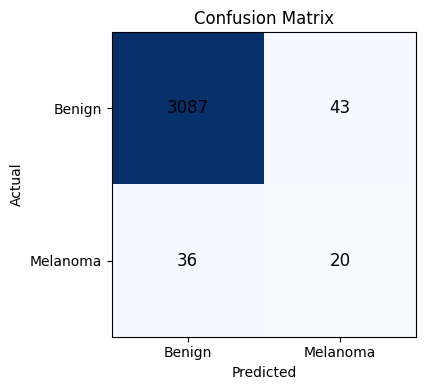

In [14]:
cm = confusion_matrix(true_labels, val_preds)

print("Classification Report:")
print(classification_report(true_labels, val_preds, target_names=["Benign", "Melanoma"]))
print(f"\nB7 hybrid model AUC: {val_auc:.4f}")

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix")
plt.xticks([0, 1], ["Benign", "Melanoma"])
plt.yticks([0, 1], ["Benign", "Melanoma"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"confusion_matrix_{EXPERIMENT_NAME}.png", dpi=150)
plt.show()


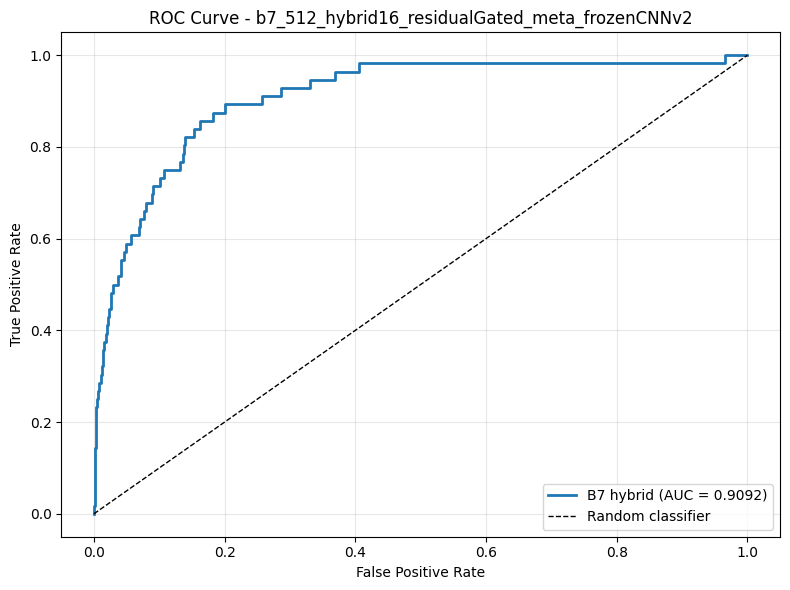

ROC curve saved.


In [15]:
fpr, tpr, _ = roc_curve(true_labels, val_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"B7 hybrid (AUC = {val_auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {EXPERIMENT_NAME}")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"roc_curve_{EXPERIMENT_NAME}.png", dpi=150)
plt.show()

print("ROC curve saved.")


In [ ]:
# Add test prediction + submission (in case we want to submit to Kaggle)

def predict_test_loader(model, loader):
    model.eval()

    all_probs = []
    all_names = []

    with torch.no_grad():
        for images, metas, names in tqdm(loader, desc="Test TTA", leave=False):
            images = images.to(device, non_blocking=True)
            metas = metas.to(device, non_blocking=True)

            if CHANNELS_LAST and device.type == "cuda":
                images = images.contiguous(memory_format=torch.channels_last)

            tta_probs = torch.zeros(images.size(0), device=device)

            for mode in TTA_MODES:
                aug_images = tta_transform(images, mode)
                logits = model(aug_images, metas)
                tta_probs += torch.sigmoid(logits)

            tta_probs /= len(TTA_MODES)

            all_probs.extend(tta_probs.cpu().numpy())
            all_names.extend(names)

    return np.array(all_names), np.array(all_probs)


test_names, test_probs = predict_test_loader(model, test_loader)

test_pred_df = pd.DataFrame({
    "image_name": test_names,
    "target": test_probs,
})

test_pred_df.to_csv(TEST_PRED_PATH, index=False)

submission = sample_sub.drop(columns=["target"], errors="ignore").merge(
    test_pred_df,
    on="image_name",
    how="left",
)

submission["target"] = submission["target"].fillna(0.0)
submission.to_csv(SUBMISSION_PATH, index=False)

print("Saved test predictions:", TEST_PRED_PATH)
print("Saved submission:", SUBMISSION_PATH)
print(submission.head())

Test TTA:   0%|          | 0/2746 [00:00<?, ?it/s]

Saved test predictions: /vol/research/ep01372/outputs_b7_512_hybrid16_residualGated_meta_frozenCNNv2/test_predictions_b7_512_hybrid16_residualGated_meta_frozenCNNv2.csv
Saved submission: /vol/research/ep01372/outputs_b7_512_hybrid16_residualGated_meta_frozenCNNv2/submission_b7_512_hybrid16_residualGated_meta_frozenCNNv2.csv
     image_name        target
0  ISIC_0052060  6.207900e-07
1  ISIC_0052349  6.226904e-05
2  ISIC_0058510  9.015533e-05
3  ISIC_0073313  7.231320e-04
4  ISIC_0073502  1.292875e-05


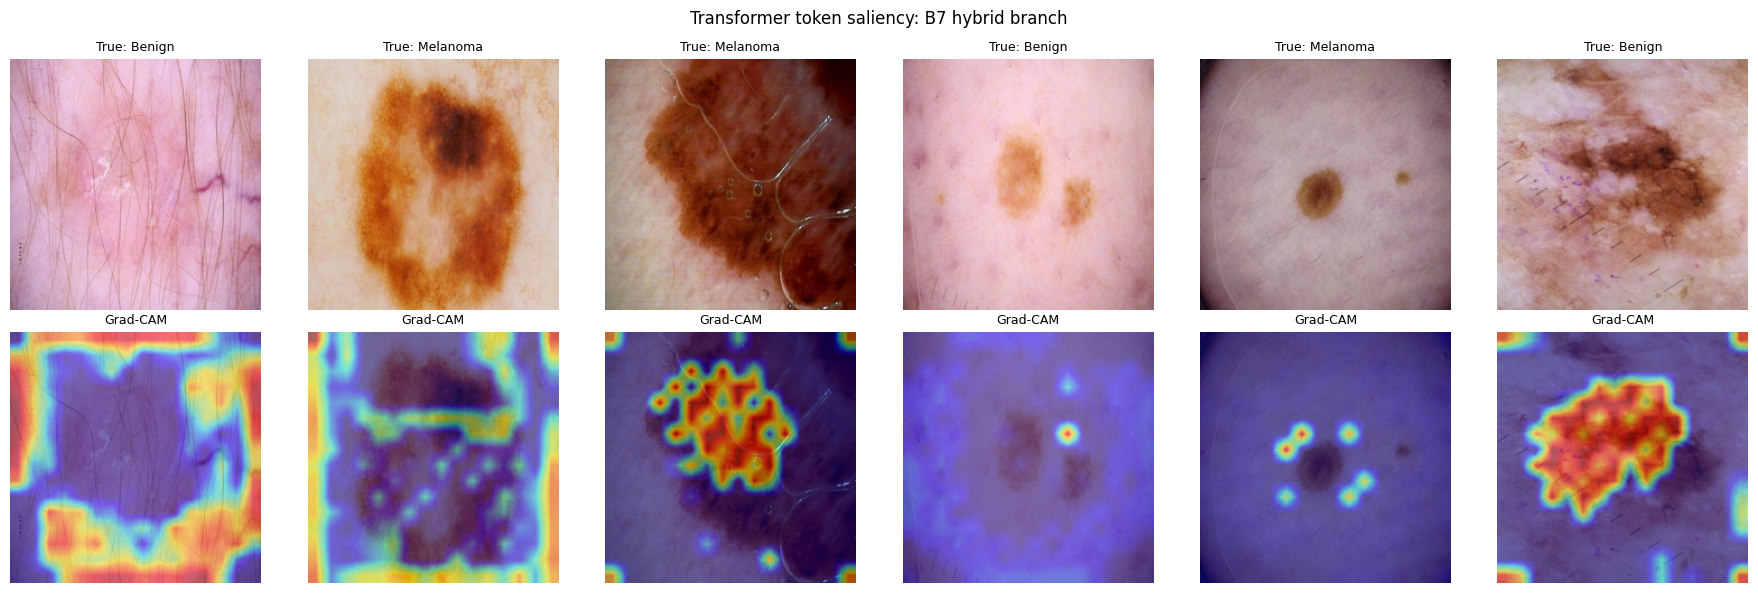

In [21]:
def get_transformer_token_cam(model, image_tensor, meta_tensor=None):
    """
    Token-level saliency map for the Transformer branch only.
    Produces a 16x16 heatmap from Transformer token relevance.
    """

    model.eval()
    base = model.module if isinstance(model, nn.DataParallel) else model

    image_tensor = image_tensor.unsqueeze(0).to(device)

    if CHANNELS_LAST and device.type == "cuda":
        image_tensor = image_tensor.contiguous(memory_format=torch.channels_last)

    base.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda", enabled=False):
        # CNN feature extractor, but detached so attribution is not to CNN
        spatial = base.backbone(image_tensor).detach()

        # Transformer branch only
        token_map = base.token_projection(spatial)              # [B, E, H, W]
        tokens = token_map.flatten(2).transpose(1, 2)            # [B, 256, E]
        tokens = tokens + base.pos_embed
        tokens = base.pos_drop(tokens)

        tokens = base.transformer(tokens)                        # [B, 256, E]
        tokens.retain_grad()                                     # needed for non-leaf tensor grads

        pooled = tokens.mean(dim=1)
        transformer_embedding = base.transformer_norm(pooled)
        transformer_logit = base.transformer_head(transformer_embedding).squeeze()

    transformer_logit.float().backward()

    if tokens.grad is None:
        raise RuntimeError("No Transformer token gradients captured.")

    # Token relevance: activation * gradient
    token_relevance = (tokens.grad * tokens).sum(dim=-1).squeeze(0)  # [256]
    token_relevance = F.relu(token_relevance)

    token_grid = token_relevance.reshape(
        base.token_grid_size,
        base.token_grid_size
    )

    token_grid = token_grid - token_grid.min()
    token_grid = token_grid / (token_grid.max() + 1e-8)

    return token_grid.detach().cpu().numpy()


def show_gradcam(model, val_df, val_transform, n_samples=6):
    melanoma_rows = val_df[val_df["target"] == 1].sample(n_samples // 2, random_state=0)
    benign_rows = val_df[val_df["target"] == 0].sample(n_samples // 2, random_state=0)
    samples = pd.concat([melanoma_rows, benign_rows]).sample(frac=1, random_state=0)

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))

    for col, (_, row) in enumerate(samples.iterrows()):
        img_path = row["image_path"]

        orig_img = Image.open(img_path).convert("RGB").resize((224, 224))

        image_np = np.array(Image.open(img_path).convert("RGB"))
        image_tensor = val_transform(image=image_np)["image"]

        meta_tensor = torch.tensor(
            row[META_FEATURES].values.astype(float),
            dtype=torch.float32,
        )

        cam = get_transformer_token_cam(model, image_tensor, meta_tensor)

        cam_resized = cv2.resize(cam, (224, 224))
        heatmap = plt.cm.jet(cam_resized)[:, :, :3]
        overlay = np.array(orig_img) / 255.0 * 0.5 + heatmap * 0.5

        true_label = "Melanoma" if row["target"] == 1 else "Benign"

        axes[0, col].imshow(orig_img)
        axes[0, col].set_title(f"True: {true_label}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(overlay)
        axes[1, col].set_title("Grad-CAM", fontsize=9)
        axes[1, col].axis("off")


    plt.suptitle("Transformer token saliency: B7 hybrid branch", fontsize=12)
    plt.tight_layout()

    plt.savefig(OUTPUT_DIR / f"transformer_token_saliency_{EXPERIMENT_NAME}.png", dpi=150)

    plt.show()



show_gradcam(model, val_df, val_transform, n_samples=6)